In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

import torch.multiprocessing as mp
import os
import torch
import torch.multiprocessing as mp
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from tqdm import tqdm
import wandb
from typing import Callable, List

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)


class DistributedTrainer:
    def __init__(
        self,
        model: torch.nn.Module,
        loss_func: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        metrics: List[Callable],
        scheduler: torch.optim.lr_scheduler._LRScheduler,
        device: torch.device,
        
        rank: int,
        world_size: int,
        save_every: int,
        model_path: str,
        
        early_stopping_patience: int = None,
    ) -> None:
        self.model = DDP(model.to(device), device_ids=[rank], output_device=rank)
        self.loss_func = loss_func
        self.optimizer = optimizer
        self.metrics = metrics
        self.scheduler = scheduler
        self.device = device
        
        self.rank = rank
        self.world_size = world_size
        self.save_every = save_every
        self.model_path = model_path
        
        self.early_stopping_patience = early_stopping_patience
        self.best_metric = None
        self.epochs_without_improvement = 0

    def train(self, train_loader, epochs, valid_loader=None, cv_loader=None, tracking=False):
        for epoch in range(epochs):
            train_loader.sampler.set_epoch(epoch)
    
            if self.rank == 0:
                print(f"Epoch {epoch+1}/{epochs}")
            self.run_epoch(train_loader, mode='train', tracking=tracking)
            if valid_loader:
                valid_loader.sampler.set_epoch(epoch)
                early_stop = self.run_epoch(valid_loader, mode='valid', tracking=tracking)
                if cv_loader:
                    cv_loader.sampler.set_epoch(epoch)
                    _ = self.run_epoch(cv_loader, mode='valid', tracking=tracking)
                if early_stop:
                    if self.rank == 0:
                        print("Early stopping triggered.")
                    break 
                
            if self.save_every and (epoch + 1) % self.save_every == 0 and self.rank == 0:
                self.save_model(epoch + 1)

                
    def validate(self, valid_loader, tracking=False):
        self.run_epoch(valid_loader, mode='valid', tracking=tracking)

    def run_epoch(self, data_loader, mode='train', tracking=False):
        if mode == 'train':
            self.model.train()
        else:
            self.model.eval()

        data_size = len(data_loader.dataset)
        total_loss = 0.0
        metric_values = {metric.__name__: 0.0 for metric in self.metrics}

        for i, batch in enumerate(tqdm(data_loader, disable=self.rank != 0)):
            loss, batch_metrics = self.run_batch(batch, mode)
            total_loss += loss * batch[0].size(0)
            for metric_name, metric_value in batch_metrics.items():
                metric_values[metric_name] += metric_value * batch[0].size(0)

            if tracking and self.rank == 0:
                self.log_wandb({f"{mode}_loss": loss, **batch_metrics})

        avg_loss = total_loss / data_size
        avg_metrics = {metric: value / data_size for metric, value in metric_values.items()}
        if self.rank == 0:
            print(f"{mode.capitalize()}: Loss: {avg_loss:.4f}, " + ", ".join([f"{metric}: {value * 100:.4f}%" for metric, value in avg_metrics.items()]))

        if mode == 'valid' and self.early_stopping_patience is not None:
            primary_metric = list(self.metrics)[0].__name__  # Assuming the first metric is the primary one for early stopping
            if self.best_metric is None or avg_metrics[primary_metric] > self.best_metric:
                self.best_metric = avg_metrics[primary_metric]
                self.epochs_without_improvement = 0
            else:
                self.epochs_without_improvement += 1
                if self.epochs_without_improvement >= self.early_stopping_patience:
                    return True  # Indicate early stopping

    def run_batch(self, batch, mode):
        inputs = batch[0].to(self.device).float()
        labels = batch[1].to(self.device).long()

        if mode == 'train':
            self.optimizer.zero_grad()

        with torch.set_grad_enabled(mode == 'train'):
            outputs = self.model(inputs)
            loss = self.loss_func(outputs, labels)
            batch_metrics = {metric.__name__: metric(outputs, labels) for metric in self.metrics}

            if mode == 'train':
                loss.backward()
                self.optimizer.step()
                if self.scheduler:
                    self.scheduler.step()

        return loss.item(), batch_metrics

    def save_model(self, epoch):
        if self.rank == 0:
            torch.save(self.model.module.state_dict(), f"{self.model_path}/model_epoch_{epoch}.pth")
            print(f"Model saved at epoch {epoch}")

    def log_wandb(self, metrics):
        if self.rank == 0:
            wandb.log(metrics)

In [2]:

def main(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'
    
    torch.distributed.init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)

    # Example dataset and dataloader
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    train_sampler = torch.utils.data.distributed.DistributedSampler(train_dataset, num_replicas=world_size, rank=rank)
    train_loader = DataLoader(train_dataset, batch_size=64, sampler=train_sampler)

    # Example model, loss function, optimizer, and metrics
    model = torch.nn.Sequential(torch.nn.Flatten(), torch.nn.Linear(28 * 28, 10))
    loss_func = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    metrics = [accuracy]

    # Create and run the distributed trainer
    # Create and run the trainer
    trainer = DistributedTrainer(
        model=model,
        loss_func=loss_func,
        optimizer=optimizer,
        metrics=metrics,
        scheduler=None,
        device=rank,
        rank=rank,
        world_size=world_size,
        save_every=5,
        model_path='./models'
    )
    trainer.train(train_loader, epochs=10)

    torch.distributed.destroy_process_group()

In [3]:
world_size = torch.cuda.device_count()
mp.spawn(main, args=(world_size,), nprocs=world_size, join=True)

ProcessExitedException: process 1 terminated with exit code 1

In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/')
from build_model import resnet50_yichen
from dataset_functions import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

from trainer_ import Trainer, accuracy

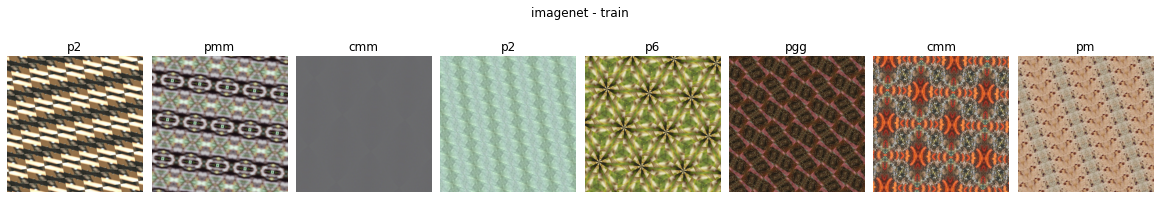

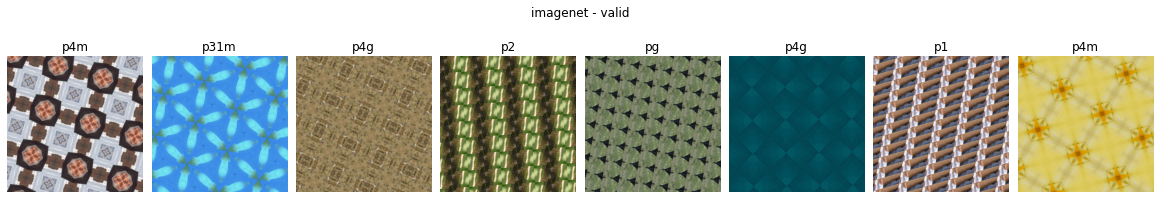

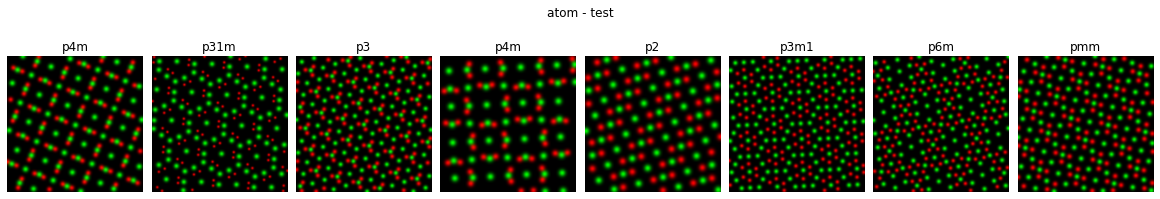

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('/scratch/yg446/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=1)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet
valid_ds = hdf5_dataset('/scratch/yg446/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=64, shuffle=False, num_workers=1)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
cv_ds = hdf5_dataset('/scratch/yg446/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transforms.ToTensor())
cv_dl = DataLoader(cv_ds, batch_size=64, shuffle=False, num_workers=1)
viz_dataloader(cv_dl, label_converter=label_converter, title='atom - test')

In [3]:
model = resnet50_yichen(in_channels=3, n_classes=17)
print(model)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
# device = torch.device('cuda:0')
device = torch.device('cpu')
model = resnet50_yichen(in_channels=3, n_classes=17).to(device)
# print(model)
outputs = model(torch.randn(2,3,256,256).to(device))
print(outputs.shape)

torch.Size([2, 17])


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

lr = 1e-3
max_epochs = 3
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=max_epochs, max_lr=lr, steps_per_epoch=len(train_dl))

trainer = Trainer(
    model=model,
    loss_func=loss_func,
    optimizer=optimizer,
    metrics=[accuracy],
    scheduler=scheduler,
    device=device,
    save_every=2,
    model_path='./',
    early_stopping_patience=1
    )

In [6]:
# Train the model
trainer.train(train_dl, epochs=max_epochs, valid_loader=valid_dl, cv_loader=cv_dl, tracking=False)

  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1/3


  0%|          | 0/1563 [00:00<?, ?it/s]

Train: Loss: 2.9325, accuracy: 6.8510%


  9%|▊         | 134/1563 [00:17<03:02,  7.83it/s]


KeyboardInterrupt: 

In [11]:
import torch
import torch.multiprocessing as mp
from multigpu import ddp_setup, load_train_objs, prepare_dataloader, destroy_process_group

ModuleNotFoundError: No module named 'multigpu'

In [6]:
def main(rank: int, world_size: int, save_every: int, total_epochs: int, batch_size: int):
    ddp_setup(rank, world_size)
    dataset, model, optimizer = load_train_objs()
    train_data = prepare_dataloader(dataset, batch_size)
    trainer = Trainer(model, train_data, optimizer, rank, save_every)
    trainer.train(total_epochs)
    destroy_process_group()

In [1]:
import torch
import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import os
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from multigpu import main, MyTrainDataset
world_size = torch.cuda.device_count()
total_epochs = 50
model = torch.nn.Linear(20, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
mp.spawn(main, args=(world_size, total_epochs, model, optimizer), nprocs=world_size)

In [1]:
import torch
from torch.utils.data import Dataset

class MyTrainDataset(Dataset):
    def __init__(self, size):
        self.size = size
        self.data = [(torch.rand(20), torch.rand(1)) for _ in range(size)]

    def __len__(self):
        return self.size
    
    def __getitem__(self, index):
        return self.data[index]

In [2]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# from datautils import MyTrainDataset

import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import os


def ddp_setup(rank, world_size):
    """
    Args:
        rank: Unique identifier of each process
        world_size: Total number of processes
    """
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)

class Trainer:
    def __init__(
        self,
        model: torch.nn.Module,
        train_data: DataLoader,
        optimizer: torch.optim.Optimizer,
        gpu_id: int,
        save_every: int,
    ) -> None:
        self.gpu_id = gpu_id
        self.model = model.to(gpu_id)
        self.train_data = train_data
        self.optimizer = optimizer
        self.save_every = save_every
        self.model = DDP(model, device_ids=[gpu_id])

    def _run_batch(self, source, targets):
        self.optimizer.zero_grad()
        output = self.model(source)
        loss = F.cross_entropy(output, targets)
        loss.backward()
        self.optimizer.step()

    def _run_epoch(self, epoch):
        b_sz = len(next(iter(self.train_data))[0])
        print(f"[GPU{self.gpu_id}] Epoch {epoch} | Batchsize: {b_sz} | Steps: {len(self.train_data)}")
        self.train_data.sampler.set_epoch(epoch)
        for source, targets in self.train_data:
            source = source.to(self.gpu_id)
            targets = targets.to(self.gpu_id)
            self._run_batch(source, targets)

    def _save_checkpoint(self, epoch):
        ckp = self.model.module.state_dict()
        PATH = "checkpoint.pt"
        torch.save(ckp, PATH)
        print(f"Epoch {epoch} | Training checkpoint saved at {PATH}")

    def train(self, max_epochs: int):
        for epoch in range(max_epochs):
            self._run_epoch(epoch)
            if self.gpu_id == 0 and epoch % self.save_every == 0:
                self._save_checkpoint(epoch)


def load_train_objs():
    train_set = MyTrainDataset(2048)  # load your dataset
    model = torch.nn.Linear(20, 1)  # load your model
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
    return train_set, model, optimizer


def prepare_dataloader(dataset: Dataset, batch_size: int):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        pin_memory=True,
        shuffle=False,
        sampler=DistributedSampler(dataset)
    )


def main(rank: int, world_size: int, save_every: int, total_epochs: int, batch_size: int):
    ddp_setup(rank, world_size)
    dataset, model, optimizer = load_train_objs()
    train_data = prepare_dataloader(dataset, batch_size)
    trainer = Trainer(model, train_data, optimizer, rank, save_every)
    trainer.train(total_epochs)
    destroy_process_group()
    
# if __name__ == "__main__":
#     import argparse
#     parser = argparse.ArgumentParser(description='simple distributed training job')
#     parser.add_argument('total_epochs', type=int, help='Total epochs to train the model')
#     parser.add_argument('save_every', type=int, help='How often to save a snapshot')
#     parser.add_argument('--batch_size', default=32, type=int, help='Input batch size on each device (default: 32)')
#     args = parser.parse_args()
    
#     world_size = torch.cuda.device_count()
#     mp.spawn(main, args=(world_size, args.save_every, args.total_epochs, args.batch_size), nprocs=world_size)

In [3]:
def spawn_main(rank, world_size, save_every, total_epochs, batch_size):
    main(rank, world_size, save_every, total_epochs, batch_size)
    
# Set your parameters
total_epochs = 50
save_every = 10
batch_size = 32
world_size = torch.cuda.device_count()

# Call mp.spawn
mp.spawn(spawn_main, 
         args=(world_size, save_every, total_epochs, batch_size), 
         nprocs=world_size, 
         join=True)

ProcessExitedException: process 0 terminated with exit code 1

In [4]:
total_epochs = 50
save_every = 10
batch_size = 32

# Function to run in each process
def run(rank, world_size, save_every, total_epochs, batch_size):
    main(rank, world_size, save_every, total_epochs, batch_size)

# Start the multiprocessing
world_size = torch.cuda.device_count()
processes = []
for rank in range(world_size):
    p = mp.Process(target=run, args=(rank, world_size, save_every, total_epochs, batch_size))
    p.start()
    processes.append(p)

for p in processes:
    p.join()

Process Process-4:
Process Process-3:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/ifs/opt/python/anaconda3/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/ifs/opt/python/anaconda3/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/ifs/opt/python/anaconda3/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "<ipython-input-4-8bf1fc51bc2e>", line 7, in run
    main(rank, world_size, save_every, total_epochs, batch_size)
  File "<ipython-input-2-ffa1e54ed377>", line 88, in main
    dataset, model, optimizer = load_train_objs()
  File "<ipython-input-2-ffa1e54ed377>", line 70, in load_train_objs
    train_set = MyTrainDataset(2048)  # load your dataset
  File "/ifs/opt/python/anaconda3/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "<ipython-input-4